In [ ]:
import fm  # for development with RNA-FM

from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np

from Bio import SeqIO  # for file parsing

from sklearn.manifold import TSNE  # for dimension reduction

from sklearn.model_selection import train_test_split  # for splitting train/val/test

from tqdm.notebook import tqdm  # for showing progress

import matplotlib.pyplot as plt

/projects/wanunulab/qinixia/software/envs/RNA-FM/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
if torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

print(f'using {device} device')

data_dir = '/projects/wanunulab/qinixia/projects/ai_agent/nanoporePlus/deps/RNA-FM/tutorials/tutorial_data'
!ls '/projects/wanunulab/qinixia/projects/ai_agent/nanoporePlus/deps/RNA-FM/tutorials/tutorial_data'

using cuda device
RF00001.fasta  RF00010.fasta
RF00005.fasta  format_rnacentral_active.100.sample-Max50.fasta


# Task1 RNA Family Clustering

In [3]:
# load fasta data
fasta_paths = list(Path(data_dir).glob('RF*.fasta'))
fasta_paths.sort()
print(fasta_paths)

[PosixPath('/projects/wanunulab/qinixia/projects/ai_agent/nanoporePlus/deps/RNA-FM/tutorials/tutorial_data/RF00001.fasta'), PosixPath('/projects/wanunulab/qinixia/projects/ai_agent/nanoporePlus/deps/RNA-FM/tutorials/tutorial_data/RF00005.fasta'), PosixPath('/projects/wanunulab/qinixia/projects/ai_agent/nanoporePlus/deps/RNA-FM/tutorials/tutorial_data/RF00010.fasta')]


In [4]:
rfam_list = []  # list of RNA families

seqs = []  # list of two-element tuples [(sequence ID, sequence),]
labels = []  # list of labels correspond to each entry in the seqs list, the labels are the RNA families

for fasta_path in fasta_paths:
    rfam = fasta_path.stem
    rfam_list.append(rfam)
    print(rfam)

    records = list(SeqIO.parse(fasta_path, 'fasta'))

    fasta_seqs = [str(record.seq) for record in records]
    fasta_seq_names = [record.id for record in records]

    seqs += [(seq_name, seq) for seq_name, seq in zip(fasta_seq_names, fasta_seqs)]

    labels += [rfam] * len(fasta_seq_names)

    print(len(seqs), len(labels))
# examine the data
print(seqs[:2])

RF00001
712 712
RF00005
1666 1666
RF00010
2124 2124
[('X01556.1/3-118', 'CUUGACGAUCAUAGAGCGUUGGAACCACCUGAUCCCUUCCCGAACUCAGAAGUGAAACGACGCAUCGCCGAUGGUAGUGUGGGGUUUCCCCAUGUGAGAGUAGGUCAUCGUCAAGC'), ('X55260.1/3-119', 'UACGGCGGCCAUAGCGAAGGGGAAAUACCCGGUCCCAUCCCGAACCCGGAAGUCAAGCCCUUCAGCGCCGAUGGUACUGCAACCGAGAGGCUGUGGGAGAGUAGGACGCCGCCGGAC')]


In [5]:
# Load RNA-FM model
fm_model, alphabet = fm.pretrained.rna_fm_t12(Path(data_dir, 'RNA-FM_pretrained.pth'))
batch_converter = alphabet.get_batch_converter()

fm_model.to(device)  # use GPU if available

fm_model.eval()  # disables dropout for deterministic results

BioBertModel(
  (embed_tokens): Embedding(25, 640, padding_idx=1)
  (layers): ModuleList(
    (0): TransformerLayer(
      (self_attn): MultiheadAttention(
        (k_proj): Linear(in_features=640, out_features=640, bias=True)
        (v_proj): Linear(in_features=640, out_features=640, bias=True)
        (q_proj): Linear(in_features=640, out_features=640, bias=True)
        (out_proj): Linear(in_features=640, out_features=640, bias=True)
      )
      (self_attn_layer_norm): LayerNorm((640,), eps=1e-05, elementwise_affine=True)
      (fc1): Linear(in_features=640, out_features=5120, bias=True)
      (fc2): Linear(in_features=5120, out_features=640, bias=True)
      (final_layer_norm): LayerNorm((640,), eps=1e-05, elementwise_affine=True)
    )
    (1): TransformerLayer(
      (self_attn): MultiheadAttention(
        (k_proj): Linear(in_features=640, out_features=640, bias=True)
        (v_proj): Linear(in_features=640, out_features=640, bias=True)
        (q_proj): Linear(in_features=6

In [6]:
chunk_size = 20

# pre-allocate the space to save memory
token_embeddings = np.zeros((len(labels), 1024, 640))

# divide all the sequences into chunks for processing due to the GPU memory limit
for i in tqdm(range(0, len(seqs), chunk_size)):
    data = seqs[i:i+chunk_size]

    batch_labels, batch_strs, batch_tokens = batch_converter(data)

    # use GPU
    with torch.no_grad():
        results = fm_model(batch_tokens.to(device), repr_layers=[12])

    emb = results['representations'][12].cpu().numpy()

    token_embeddings[i:i+chunk_size, :emb.shape[1], :] = emb


print(token_embeddings.shape)

  0%|          | 0/107 [00:00<?, ?it/s]

(2124, 1024, 640)


In [13]:
token_embeddings = np.mean(token_embeddings, axis=1)

print(token_embeddings.shape)
# t-SNE
tsne = TSNE(n_components=2, random_state=42)  # n_components is the dimension of the reduced data

embeddings = tsne.fit_transform(token_embeddings)

print(embeddings.shape)

(2124, 640)
(2124, 2)


## Visualization

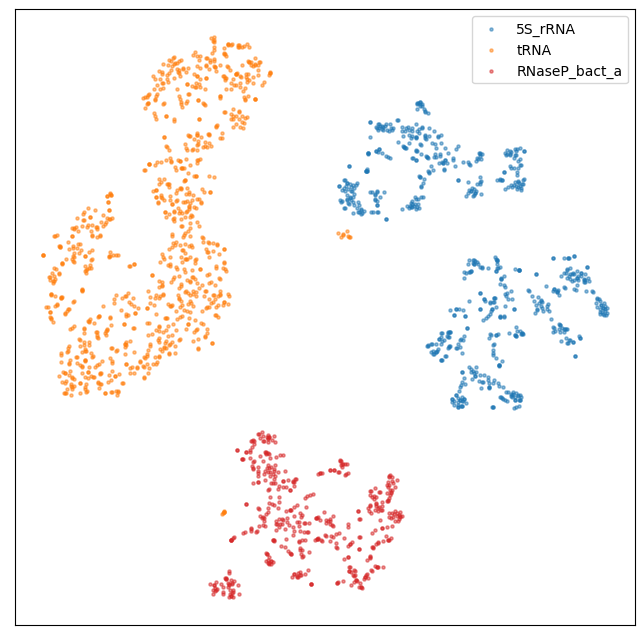

In [14]:
colors = ['tab:blue', 'tab:orange', 'tab:red']
rfam_dict = {'RF00001': '5S_rRNA', 'RF00005': 'tRNA', 'RF00010': 'RNaseP_bact_a'}  # map the Rfam index to name

plt.figure(figsize=(8, 8))

for i, label in enumerate(sorted(list(set(labels)))):
    # find the data points corresponding to the current label
    indices = [j for j, l in enumerate(labels) if l == label]
    plt.scatter(embeddings[indices, 0], embeddings[indices, 1], color=colors[i], s=5, alpha=0.5, label=rfam_dict[label])


plt.legend()
plt.xticks([])
plt.yticks([])

plt.show()

#  Task 2 RNA Type Classification